# 06 - Pretrain DeepHpx Embedding

This notebook runs hotspot/U-Net pretraining and exports a pretrained embedding for later NPE flow training.


In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

from pretrain_deephpx_embedding import (
    EmbeddingArchitecture,
    PretrainConfig,
    pretrain_deephpx_embedding,
    load_history_csv,
    plot_training_diagnostics,
    load_pretrained_embedding_net,
)

plt.style.use('seaborn-v0_8-whitegrid')


In [2]:
PROJECT_ROOT = Path.cwd().resolve().parents[0]
DATA_ROOT = Path('/mnt/my-ssd/Data_for_IceCube_Population_Project')
SIM_BANK_DIR = DATA_ROOT / 'Sims' / 'Capel_wide'
THETA_CSV = SIM_BANK_DIR / 'theta.csv'
OUTDIR = DATA_ROOT / 'Sims' / 'Capel_wide_embedding_pretrain_nside128'

for p in (SIM_BANK_DIR, THETA_CSV):
    print(p, 'exists=', p.exists())

maps_zarr = SIM_BANK_DIR / 'maps_counts.zarr'
maps_npy = SIM_BANK_DIR / 'maps_counts.npy'
print('maps_counts.zarr exists:', maps_zarr.exists())
print('maps_counts.npy exists :', maps_npy.exists())


DIAG_PLOTS_DIR = THETA_CSV.parent
DIAG_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
print('Diagnostic plots dir:', DIAG_PLOTS_DIR)


/mnt/my-ssd/Data_for_IceCube_Population_Project/Sims/Capel_wide exists= True
/mnt/my-ssd/Data_for_IceCube_Population_Project/Sims/Capel_wide/theta.csv exists= True
maps_counts.zarr exists: True
maps_counts.npy exists : False
Diagnostic plots dir: /mnt/my-ssd/Data_for_IceCube_Population_Project/Sims/Capel_wide


In [ ]:
arch = EmbeddingArchitecture(
    cheb_K=5,
    min_nside=2,
    first_hidden=16,
    max_hidden=512,
    pool='max',
    norm='batch',
    embedding_dim=256,
    embedding_mlp_hidden=(),
)

BATCH_SIZES_TO_TRY = [128, 64, 32]

cfg = PretrainConfig(
    label_mode='truth_sparse',
    truth_top_k=4,
    dilate_steps=1,
    batch_size=BATCH_SIZES_TO_TRY[0],
    max_epochs=12,
    early_stopping_patience=3,
    lr_scheduler_patience=2,
    learning_rate=4e-4,
    seed=4698,
)

print('Architecture:', arch)
print('Batch sizes to try:', BATCH_SIZES_TO_TRY)
print('Training config:', cfg)

DEEPHPX_SRC = PROJECT_ROOT / 'external' / 'DeepHpx' / 'src'


Architecture: EmbeddingArchitecture(cheb_K=5, laplacian_kind='normalized', cheb_lmax=2.0, min_nside=2, first_hidden=12, max_hidden=256, pool='max', norm='batch', group_norm_groups=16, dropout=0.0, embedding_dim=192, append_input_stats=True, input_stats_mode='per_channel', embedding_mlp_hidden=())
Batch sizes to try: [8, 6, 4]
Training config: PretrainConfig(target_columns=(), ridge_alpha=0.001, input_ordering='RING', target_ordering='NEST', log1p_inputs=False, standardize_inputs=True, train_fraction=0.8, val_fraction=0.1, seed=4698, batch_size=8, num_workers=0, learning_rate=0.0004, weight_decay=0.0001, max_epochs=12, early_stopping_patience=3, min_delta=0.0001, grad_clip_norm=5.0, lr_scheduler_patience=2, lr_scheduler_factor=0.5, amp=True, label_mode='truth_sparse', counts_threshold=None, target_mean_hotspots=4, top_k_hotspots=4, truth_top_k=4, pseudo_smooth_steps=1, dilate_steps=1, pseudo_score_weights='inv_mean', loss_mode='focal_dice', focal_gamma=2.0, focal_alpha=0.25, dice_weight

In [4]:
import gc
from dataclasses import replace

import torch

rep = None
last_err = None

for batch_size in BATCH_SIZES_TO_TRY:
    cfg_try = replace(cfg, batch_size=batch_size)
    print(f'Trying batch_size={batch_size}')
    try:
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

        rep = pretrain_deephpx_embedding(
            maps_counts_path=SIM_BANK_DIR,     # pass sim_dir directly (maps_counts.zarr preferred)
            theta_csv_path=THETA_CSV,
            outdir=OUTDIR,
            arch=arch,
            cfg=cfg_try,
            device='auto',
            project_root=PROJECT_ROOT,
            deephpx_src_override=DEEPHPX_SRC,
        )
        cfg = cfg_try
        print(f'Training succeeded with batch_size={batch_size}')
        break
    except RuntimeError as err:
        if 'out of memory' not in str(err).lower():
            raise
        last_err = err
        print(f'CUDA OOM at batch_size={batch_size}; trying a smaller batch.')
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

if rep is None:
    raise RuntimeError('Training failed for all candidate batch sizes.') from last_err

art = rep['artifacts']
print('full checkpoint    :', art.full_checkpoint)
print('embedding checkpoint:', art.embedding_checkpoint)
print('metrics            :', art.metrics_json)


Trying batch_size=8
[pretrain] AMP requested, but CUDA sparse.mm(float16) is not supported in this PyTorch/CUDA build. Falling back to full precision.


/home/oamacias/miniconda3/envs/ili-torch/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


[epoch 0001] train_loss=0.146 val_loss=0.1583 val_f1=0.289 lr=4.00e-04 elapsed=1h28m eta_early=4h26m eta_max=16h18m  (best)
[epoch 0002] train_loss=0.1322 val_loss=0.1597 val_f1=0.289 lr=4.00e-04 elapsed=2h57m eta_early=2h57m eta_max=14h47m
[epoch 0003] train_loss=0.1306 val_loss=0.1404 val_f1=0.389 lr=4.00e-04 elapsed=4h25m eta_early=4h25m eta_max=13h17m  (best)
[epoch 0004] train_loss=0.1298 val_loss=0.1404 val_f1=0.372 lr=4.00e-04 elapsed=5h54m eta_early=2h57m eta_max=11h48m
[epoch 0005] train_loss=0.1294 val_loss=0.1332 val_f1=0.382 lr=4.00e-04 elapsed=7h22m eta_early=4h25m eta_max=10h19m  (best)
[epoch 0006] train_loss=0.1288 val_loss=0.1397 val_f1=0.375 lr=4.00e-04 elapsed=8h51m eta_early=2h57m eta_max=8h51m
[epoch 0007] train_loss=0.1288 val_loss=0.1752 val_f1=0.173 lr=4.00e-04 elapsed=10h19m eta_early=1h28m eta_max=7h22m
[epoch 0008] train_loss=0.1285 val_loss=0.1391 val_f1=0.407 lr=2.00e-04 elapsed=11h47m eta_early=0s eta_max=5h53m
Early stopping at epoch 8 (best epoch 5, best

{
  "best_epoch": 5,
  "best_val_loss": 0.13320026611089705,
  "train_seconds": 42468.91329622269,
  "device": "cuda",
  "amp_requested": true,
  "amp_enabled": false,
  "label_meta": {
    "coverage": "all",
    "label_mode": "truth_sparse",
    "truth_top_k": 4,
    "dilate_steps": 1,
    "truth_nest": true,
    "n_samples": 50000,
    "npix": 196608,
    "nbytes": 24576
  },
  "final": {
    "epoch": 8,
    "train_loss": 0.12848471133038403,
    "val_loss": 0.13911826712489128,
    "val_precision": 0.8156977562729328,
    "val_recall": 0.29269823363581954,
    "val_f1": 0.4071012491763176,
    "val_iou": 0.267106923955003,
    "lr": 0.0002,
    "epoch_seconds": 5286.416805744171,
    "elapsed_seconds": 42468.91321706772,
    "eta_early_seconds": 0.0,
    "eta_max_seconds": 21234.45660853386
  },
  "pos_weight": null
}


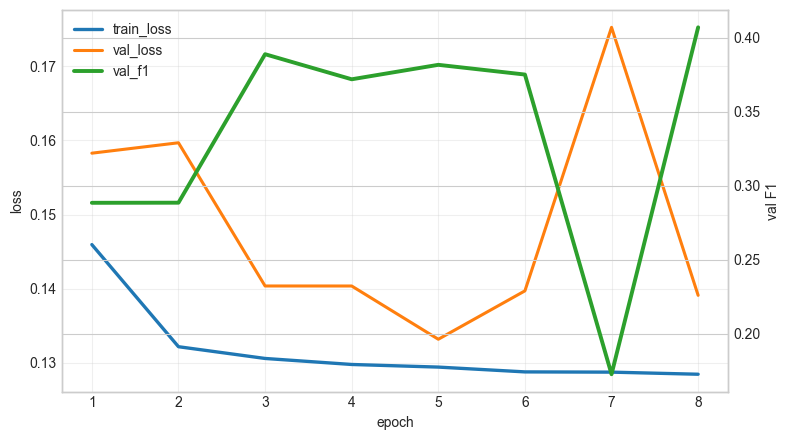

diagnostic figure: /mnt/my-ssd/Data_for_IceCube_Population_Project/Sims/Capel_wide/06_pretrain_history_diagnostics.png


In [5]:
metrics = json.loads(Path(art.metrics_json).read_text())
print(json.dumps(metrics, indent=2)[:2000])

history_plot_path = DIAG_PLOTS_DIR / '06_pretrain_history_diagnostics.png'
diag_png = plot_training_diagnostics(art.history_csv, outpath=history_plot_path, show=True)
print('diagnostic figure:', diag_png)


## Extra Validation Diagnostics

The next cells run additional checks on validation maps: threshold sweep, PR/AUPRC, peak-count calibration, and localization angular errors.


In [6]:
import torch
from torch.utils.data import DataLoader
import pretrain_deephpx_embedding as pde

# Configurable diagnostics budget
N_VAL_EVAL = 16          # set to None to evaluate the full validation split
EVAL_BATCH_SIZE = 4
THRESHOLD_GRID = np.linspace(0.05, 0.95, 37)

sim_dir, maps_path = pde._resolve_sim_dir_and_maps_path(Path(SIM_BANK_DIR))
maps_counts = pde._open_maps_counts_any(maps_path)

n_samples = int(maps_counts.shape[0])
in_channels = int(maps_counts.shape[1])
npix = int(maps_counts.shape[2])
nside = int(np.sqrt(npix / 12))

split = pde._make_split_indices(
    n_samples,
    train_fraction=float(cfg.train_fraction),
    val_fraction=float(cfg.val_fraction),
    seed=int(cfg.seed),
)

prep = rep['preprocessing']
map_mean = np.asarray(prep['map_channel_mean'], dtype=np.float32)
map_std = np.asarray(prep['map_channel_std'], dtype=np.float32)
reorder_raw = prep.get('reorder_ring_to_nest', None)
reorder_idx = None if reorder_raw is None else np.asarray(reorder_raw, dtype=np.int64)

nbytes = (npix + 7) // 8
labels_path = Path(art.cache_dir) / f"hotspot_labels_{cfg.label_mode}_packbits_nside{nside}_npix{npix}.dat"
if not labels_path.exists():
    raise FileNotFoundError(f"Missing cached labels file: {labels_path}")

labels_packbits = np.memmap(labels_path, mode='r', dtype=np.uint8, shape=(n_samples, nbytes))

val_indices = np.asarray(split.val, dtype=np.int64)
if N_VAL_EVAL is not None:
    val_indices = val_indices[: min(int(N_VAL_EVAL), val_indices.size)]

val_ds = pde.SimMapHotspotDataset(
    maps_counts,
    labels_packbits,
    val_indices,
    npix=npix,
    in_channels=in_channels,
    map_channel_mean=map_mean,
    map_channel_std=map_std,
    log1p_inputs=bool(cfg.log1p_inputs),
    reorder_index=reorder_idx,
)

device_eval = next(rep['unet'].parameters()).device
val_loader = DataLoader(
    val_ds,
    batch_size=int(EVAL_BATCH_SIZE),
    shuffle=False,
    num_workers=0,
    pin_memory=(device_eval.type == 'cuda'),
    drop_last=False,
)

probs_chunks = []
truth_chunks = []
idx_chunks = []

rep['unet'].eval()
with torch.no_grad():
    for xb, yb, ib in val_loader:
        xb = xb.to(device_eval, non_blocking=True)
        logits = rep['unet'](xb)
        probs = torch.sigmoid(logits).squeeze(-1).detach().cpu().numpy().astype(np.float32)
        truth = yb.squeeze(-1).detach().cpu().numpy().astype(np.uint8)

        probs_chunks.append(probs)
        truth_chunks.append(truth)
        idx_chunks.append(ib.detach().cpu().numpy().astype(np.int64))

val_probs = np.concatenate(probs_chunks, axis=0)
val_true = np.concatenate(truth_chunks, axis=0)
val_global_idx = np.concatenate(idx_chunks, axis=0)

print('eval maps      :', val_probs.shape[0])
print('nside / npix   :', nside, npix)
print('probs shape    :', val_probs.shape, val_probs.dtype)
print('truth shape    :', val_true.shape, val_true.dtype)
print('positive rate  :', float(val_true.mean()))


eval maps      : 16
nside / npix   : 128 196608
probs shape    : (16, 196608) float32
truth shape    : (16, 196608) uint8
positive rate  : 0.00018310546875


Best F1 threshold: 0.725
{'threshold': 0.725, 'precision': 0.6868, 'recall': 0.434, 'f1': 0.5319, 'iou': 0.3623}
saved: /mnt/my-ssd/Data_for_IceCube_Population_Project/Sims/Capel_wide/06_threshold_sweep_pr.png


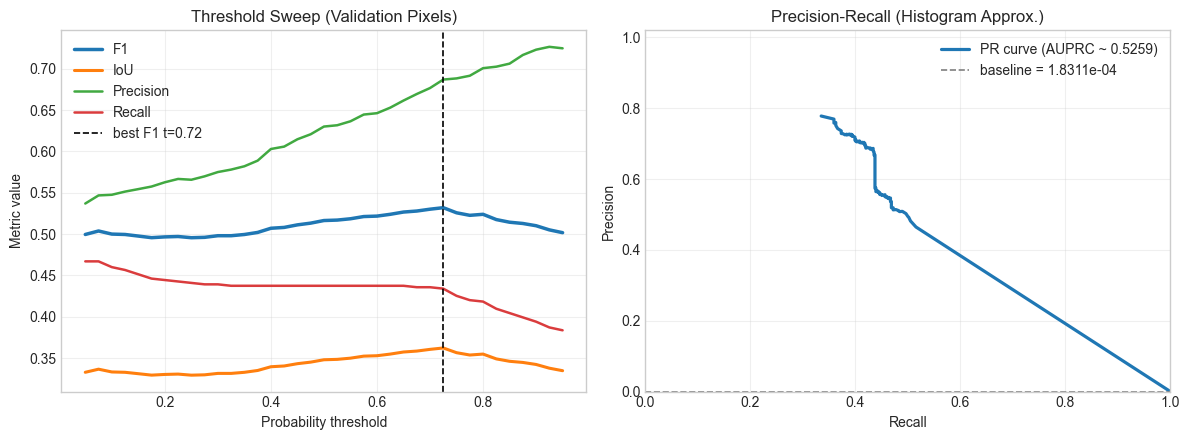

In [7]:
def _pixel_stats_at_threshold(probs: np.ndarray, truth: np.ndarray, threshold: float) -> dict:
    pred = probs >= float(threshold)
    tru = truth.astype(bool)

    tp = int(np.logical_and(pred, tru).sum())
    fp = int(np.logical_and(pred, ~tru).sum())
    fn = int(np.logical_and(~pred, tru).sum())

    precision = tp / (tp + fp + 1e-12)
    recall = tp / (tp + fn + 1e-12)
    f1 = 2.0 * precision * recall / (precision + recall + 1e-12)
    iou = tp / (tp + fp + fn + 1e-12)
    return {
        'threshold': float(threshold),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'iou': float(iou),
    }


def _pr_curve_hist(probs: np.ndarray, truth: np.ndarray, n_bins: int = 512):
    # Histogram approximation avoids sorting hundreds of millions of pixels.
    p = probs.reshape(-1)
    y = truth.reshape(-1).astype(np.uint8)

    bins = np.linspace(0.0, 1.0, int(n_bins) + 1)
    pos_hist, _ = np.histogram(p[y == 1], bins=bins)
    all_hist, _ = np.histogram(p, bins=bins)
    neg_hist = all_hist - pos_hist

    tp = np.cumsum(pos_hist[::-1]).astype(np.float64)
    fp = np.cumsum(neg_hist[::-1]).astype(np.float64)
    total_pos = float(max(1, pos_hist.sum()))

    recall = tp / total_pos
    precision = tp / np.maximum(1.0, tp + fp)
    thresholds = bins[:-1][::-1]

    recall_curve = np.concatenate([[0.0], recall])
    precision_curve = np.concatenate([[1.0], precision])
    auprc = float(np.trapz(precision_curve, recall_curve))
    return thresholds, precision, recall, auprc


sweep = [_pixel_stats_at_threshold(val_probs, val_true, t) for t in THRESHOLD_GRID]
best_row = max(sweep, key=lambda r: r['f1'])
best_threshold = float(best_row['threshold'])

print(f"Best F1 threshold: {best_threshold:.3f}")
print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in best_row.items()})

thr = np.array([r['threshold'] for r in sweep], dtype=np.float32)
prec = np.array([r['precision'] for r in sweep], dtype=np.float32)
rec = np.array([r['recall'] for r in sweep], dtype=np.float32)
f1v = np.array([r['f1'] for r in sweep], dtype=np.float32)
iouv = np.array([r['iou'] for r in sweep], dtype=np.float32)

pr_t, pr_prec, pr_rec, auprc = _pr_curve_hist(val_probs, val_true, n_bins=512)
baseline = float(val_true.mean())

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].plot(thr, f1v, color='tab:blue', linewidth=2.5, label='F1')
ax[0].plot(thr, iouv, color='tab:orange', linewidth=2.2, label='IoU')
ax[0].plot(thr, prec, color='tab:green', linewidth=1.8, alpha=0.9, label='Precision')
ax[0].plot(thr, rec, color='tab:red', linewidth=1.8, alpha=0.9, label='Recall')
ax[0].axvline(best_threshold, color='black', linestyle='--', linewidth=1.2, label=f'best F1 t={best_threshold:.2f}')
ax[0].set_xlabel('Probability threshold')
ax[0].set_ylabel('Metric value')
ax[0].set_title('Threshold Sweep (Validation Pixels)')
ax[0].grid(True, alpha=0.3)
ax[0].legend(loc='best')

ax[1].plot(pr_rec, pr_prec, color='tab:blue', linewidth=2.3, label=f'PR curve (AUPRC ~ {auprc:.4f})')
ax[1].axhline(baseline, color='tab:gray', linestyle='--', linewidth=1.2, label=f'baseline = {baseline:.4e}')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-Recall (Histogram Approx.)')
ax[1].set_xlim(0.0, 1.0)
ax[1].set_ylim(0.0, 1.02)
ax[1].grid(True, alpha=0.3)
ax[1].legend(loc='best')

plt.tight_layout()
threshold_pr_path = DIAG_PLOTS_DIR / '06_threshold_sweep_pr.png'
plt.savefig(threshold_pr_path, dpi=180, bbox_inches='tight')
print('saved:', threshold_pr_path)
plt.show()


Count MAE (pred vs truth peaks/map): 3.062
Count bias (pred - truth)         : -0.438
Localization median [deg]          : 21.624
Localization p90 [deg]             : 80.790
saved: /mnt/my-ssd/Data_for_IceCube_Population_Project/Sims/Capel_wide/06_peak_count_localization.png


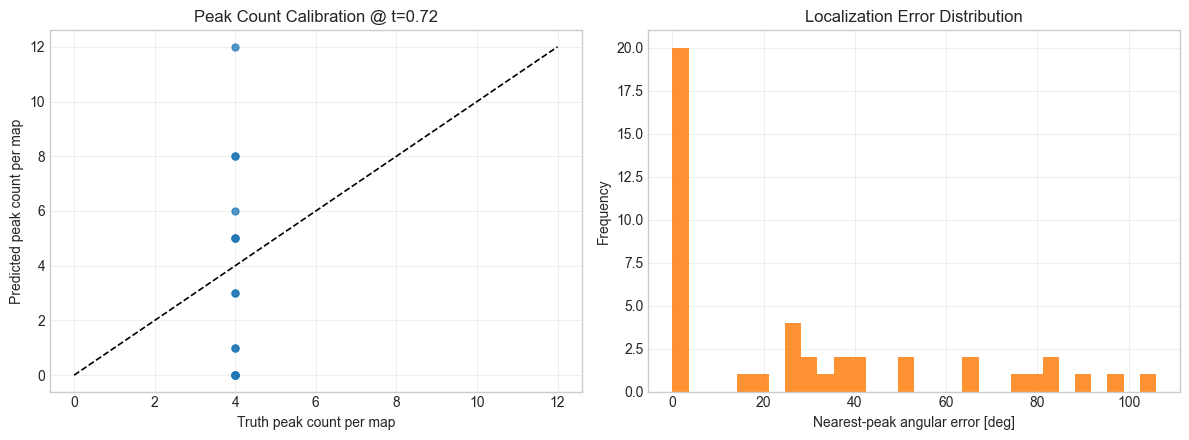

In [8]:
import healpy as hp
from deephpx.graph import neighbors_8

neigh = neighbors_8(int(nside), nest=True)

def _predict_peak_pixels(prob_map: np.ndarray, threshold: float) -> np.ndarray:
    lm = pde._local_maxima_mask(prob_map.astype(np.float32, copy=False), neigh, strict=True)
    sel = lm & (prob_map >= float(threshold))
    return np.where(sel)[0].astype(np.int64)


truth_sparse_path = pde._find_truth_sparse_candidate(Path(sim_dir))
if truth_sparse_path is None:
    print('No sparse truth file found; skipping count/localization diagnostics.')
else:
    truth = pde._load_truth_sparse(truth_sparse_path)
    indptr = np.asarray(truth['indptr'], dtype=np.int64)
    truth_indices_all = np.asarray(truth['indices'], dtype=np.int64)
    truth_values_all = np.asarray(truth['values'], dtype=np.float32)

    truth_nest = None
    if 'nest' in truth:
        truth_nest = bool(int(np.asarray(truth['nest']).reshape(-1)[0]))

    if truth_nest is False:
        truth_indices_all = hp.ring2nest(int(nside), truth_indices_all.astype(np.int64, copy=False))

    use_k = None if cfg.truth_top_k is None else int(cfg.truth_top_k)

    def _truth_peak_pixels(sim_idx: int) -> np.ndarray:
        a = int(indptr[sim_idx])
        b = int(indptr[sim_idx + 1])
        if b <= a:
            return np.empty((0,), dtype=np.int64)
        pix = truth_indices_all[a:b]
        if use_k is not None and pix.size > use_k:
            vals = truth_values_all[a:b]
            sel = pde._topk_indices(vals, use_k)
            pix = pix[sel]
        pix = pix[(pix >= 0) & (pix < npix)]
        return np.asarray(pix, dtype=np.int64)

    pred_counts = []
    truth_counts = []
    loc_errors_deg = []

    for j, sim_idx in enumerate(val_global_idx):
        pred_pix = _predict_peak_pixels(val_probs[j], best_threshold)
        truth_pix = _truth_peak_pixels(int(sim_idx))

        pred_counts.append(int(pred_pix.size))
        truth_counts.append(int(truth_pix.size))

        if pred_pix.size == 0 or truth_pix.size == 0:
            continue

        truth_vec = np.vstack(hp.pix2vec(int(nside), truth_pix, nest=True)).T.astype(np.float64)
        pred_vec = np.vstack(hp.pix2vec(int(nside), pred_pix, nest=True)).T.astype(np.float64)

        cos = np.clip(truth_vec @ pred_vec.T, -1.0, 1.0)
        best_cos = np.max(cos, axis=1)
        err_deg = np.degrees(np.arccos(best_cos))
        loc_errors_deg.extend(err_deg.tolist())

    pred_counts = np.asarray(pred_counts, dtype=np.int64)
    truth_counts = np.asarray(truth_counts, dtype=np.int64)
    loc_errors_deg = np.asarray(loc_errors_deg, dtype=np.float64)

    mae_counts = float(np.mean(np.abs(pred_counts - truth_counts)))
    bias_counts = float(np.mean(pred_counts - truth_counts))

    print(f'Count MAE (pred vs truth peaks/map): {mae_counts:.3f}')
    print(f'Count bias (pred - truth)         : {bias_counts:.3f}')
    if loc_errors_deg.size > 0:
        print(f'Localization median [deg]          : {np.median(loc_errors_deg):.3f}')
        print(f'Localization p90 [deg]             : {np.percentile(loc_errors_deg, 90):.3f}')
    else:
        print('Localization: no matched peaks to evaluate.')

    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

    lim = int(max(np.max(truth_counts), np.max(pred_counts), 1))
    ax[0].scatter(truth_counts, pred_counts, s=25, alpha=0.75, color='tab:blue')
    ax[0].plot([0, lim], [0, lim], '--', color='black', linewidth=1.2)
    ax[0].set_xlabel('Truth peak count per map')
    ax[0].set_ylabel('Predicted peak count per map')
    ax[0].set_title(f'Peak Count Calibration @ t={best_threshold:.2f}')
    ax[0].grid(True, alpha=0.3)

    if loc_errors_deg.size > 0:
        ax[1].hist(loc_errors_deg, bins=30, color='tab:orange', alpha=0.85)
        ax[1].set_xlabel('Nearest-peak angular error [deg]')
        ax[1].set_ylabel('Frequency')
        ax[1].set_title('Localization Error Distribution')
        ax[1].grid(True, alpha=0.3)
    else:
        ax[1].text(0.5, 0.5, 'No localization samples', ha='center', va='center')
        ax[1].set_axis_off()

    plt.tight_layout()
    count_localization_path = DIAG_PLOTS_DIR / '06_peak_count_localization.png'
    plt.savefig(count_localization_path, dpi=180, bbox_inches='tight')
    print('saved:', count_localization_path)
    plt.show()


In [9]:
embedding_net, bundle = load_pretrained_embedding_net(
    art.embedding_checkpoint,
    device='auto',
    project_root=PROJECT_ROOT,
    deephpx_src_override=DEEPHPX_SRC,
)

print('Loaded embedding net.')
print('nside      :', bundle['nside'])
print('in_channels:', bundle['in_channels'])


Loaded embedding net.
nside      : 128
in_channels: 5
